<a href="https://colab.research.google.com/github/ayesha-haque06/First-Machine-Learning-Project/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score




hp = pd.read_csv('/content/messy_house_prices.csv')
print("First 5 rows")
display(hp.head())
print("Last 5 rows")
hp.tail()


First 5 rows


,id,lot_area_sqft,num_bedrooms,num_bathrooms,house_stories,year_constructed,distance_to_cbd_km,has_swimming_pool,condition_rating,sale_price_usd
0,1001,6741.785383,3,1.5,3.0,1954,42.075006,Yes,Good,589886.438872
1,1002,5154.339247,4,2.0,2.0,1972,23.761515,Yes,Excellent,551547.473801
2,1003,7119.221345,3,3.0,2.0,1958,13.475672,No,Good,625037.568759
3,1004,9307.574641,2,3.0,2.0,2007,12.377018,No,Fair,780657.586651
4,1005,4914.616563,2,2.0,1.0,2008,41.863004,No,Poor,435513.688890


Last 5 rows


,id,lot_area_sqft,num_bedrooms,num_bathrooms,house_stories,year_constructed,distance_to_cbd_km,has_swimming_pool,condition_rating,sale_price_usd
1520,2200,8910.351075,3,4.0,1.0,2001,25.427649,No,Good,769021.430203
1521,2129,5339.654134,3,1.5,1.0,1953,25.071157,No,Poor,450084.140137
1522,2191,5763.438765,3,2.0,2.0,1966,NaN,No,Good,546339.236318
1523,2250,1610.260884,3,2.0,2.0,2016,32.606268,No,Fair,305417.677930
1524,2420,6769.589391,2,1.5,3.0,1999,5.832202,No,Good,609229.887464


In [42]:
print("Dataset information")
hp.info()
print("Missing values before handling")
display(hp.isnull().sum()[hp.isnull().sum() > 0].sort_values(ascending=False))
#handling missing values
hp_cleaned = hp.dropna().copy()
print("Missing values after dropping rows:")
# Re-check for missing values to confirm they are gone.
display(hp_cleaned.isnull().sum()[hp_cleaned.isnull().sum() > 0].sort_values(ascending=False))
# Identify which columns contain text and which contain numbers
text = hp_cleaned.select_dtypes(include='object').columns
numbers = hp_cleaned.select_dtypes(include=['int64', 'float64']).columns

print(f"text-based: {list(text)}")
print(f"number-based: {list(numbers)}")

hp_encoded = pd.get_dummies(hp_cleaned, columns=text, drop_first=True)
print("DataFrame after converting text to numbers (first 5 rows):")
display(hp_encoded.head())
print("DataFrame after converting text to numbers (flast 5 rows):")
display(hp_encoded.tail())

# Initialize these variables to None outside the if-else block
# so they are always defined, even if the 'sale_price_usd' column is not found
X = None
y = None
X_train = None
X_test = None
y_train = None
y_test = None
X_train_scaled = None
X_test_scaled = None


# Separate our data into two main parts
if 'sale_price_usd' in hp_encoded.columns:
    X = hp_encoded.drop('sale_price_usd', axis=1)
    y = hp_encoded['sale_price_usd']
    print("Features (X) and Target (y) are now defined.")

    # Only perform train-test split and scaling if X and y are defined
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\nTraining set (80% of data): X_train has {X_train.shape[0]} rows, y_train has {y_train.shape[0]} rows.")
    print(f"Testing set (20% of data): X_test has {X_test.shape[0]} rows, y_test has {y_test.shape[0]} rows.")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Features have been scaled using StandardScaler (made to a similar range).")
else:
    print("Error: The 'sale_price_usd' column was not found in the dataset.")
    print("Skipping further data preparation as features or target were not defined.")

Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1525 non-null   int64  
 1   lot_area_sqft       1433 non-null   float64
 2   num_bedrooms        1465 non-null   object 
 3   num_bathrooms       1525 non-null   float64
 4   house_stories       1525 non-null   float64
 5   year_constructed    1525 non-null   int64  
 6   distance_to_cbd_km  1447 non-null   float64
 7   has_swimming_pool   1509 non-null   object 
 8   condition_rating    1479 non-null   object 
 9   sale_price_usd      1525 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 119.3+ KB
Missing values before handling


,0
lot_area_sqft,92
distance_to_cbd_km,78
num_bedrooms,60
condition_rating,46
has_swimming_pool,16


Missing values after dropping rows:


,0


text-based: ['num_bedrooms', 'has_swimming_pool', 'condition_rating']
number-based: ['id', 'lot_area_sqft', 'num_bathrooms', 'house_stories', 'year_constructed', 'distance_to_cbd_km', 'sale_price_usd']
DataFrame after converting text to numbers (first 5 rows):


,id,lot_area_sqft,num_bathrooms,house_stories,year_constructed,distance_to_cbd_km,sale_price_usd,num_bedrooms_2,num_bedrooms_2 rooms,num_bedrooms_3,...,num_bedrooms_5,num_bedrooms_6,num_bedrooms_three,has_swimming_pool_YES,has_swimming_pool_Yes,has_swimming_pool_no,condition_rating_Exclnt,condition_rating_Fair,condition_rating_Good,condition_rating_Poor
0,1001,6741.785383,1.5,3.0,1954,42.075006,589886.438872,False,False,True,...,False,False,False,False,True,False,False,False,True,False
1,1002,5154.339247,2.0,2.0,1972,23.761515,551547.473801,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,1003,7119.221345,3.0,2.0,1958,13.475672,625037.568759,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,1004,9307.574641,3.0,2.0,2007,12.377018,780657.586651,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,1005,4914.616563,2.0,1.0,2008,41.863004,435513.688890,True,False,False,...,False,False,False,False,False,False,False,False,False,True


DataFrame after converting text to numbers (flast 5 rows):


,id,lot_area_sqft,num_bathrooms,house_stories,year_constructed,distance_to_cbd_km,sale_price_usd,num_bedrooms_2,num_bedrooms_2 rooms,num_bedrooms_3,...,num_bedrooms_5,num_bedrooms_6,num_bedrooms_three,has_swimming_pool_YES,has_swimming_pool_Yes,has_swimming_pool_no,condition_rating_Exclnt,condition_rating_Fair,condition_rating_Good,condition_rating_Poor
1519,1052,4537.294299,1.0,2.0,1966,19.259164,461130.207293,False,False,True,...,False,False,False,False,False,False,False,False,True,False
1520,2200,8910.351075,4.0,1.0,2001,25.427649,769021.430203,False,False,True,...,False,False,False,False,False,False,False,False,True,False
1521,2129,5339.654134,1.5,1.0,1953,25.071157,450084.140137,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1523,2250,1610.260884,2.0,2.0,2016,32.606268,305417.677930,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1524,2420,6769.589391,1.5,3.0,1999,5.832202,609229.887464,True,False,False,...,False,False,False,False,False,False,False,False,True,False


Features (X) and Target (y) are now defined.

Training set (80% of data): X_train has 1002 rows, y_train has 1002 rows.
Testing set (20% of data): X_test has 251 rows, y_test has 251 rows.
Features have been scaled using StandardScaler (made to a similar range).


Linear Regression - Mean Squared Error (MSE): 17109907667.88
Linear Regression - R-squared (R2): 0.09


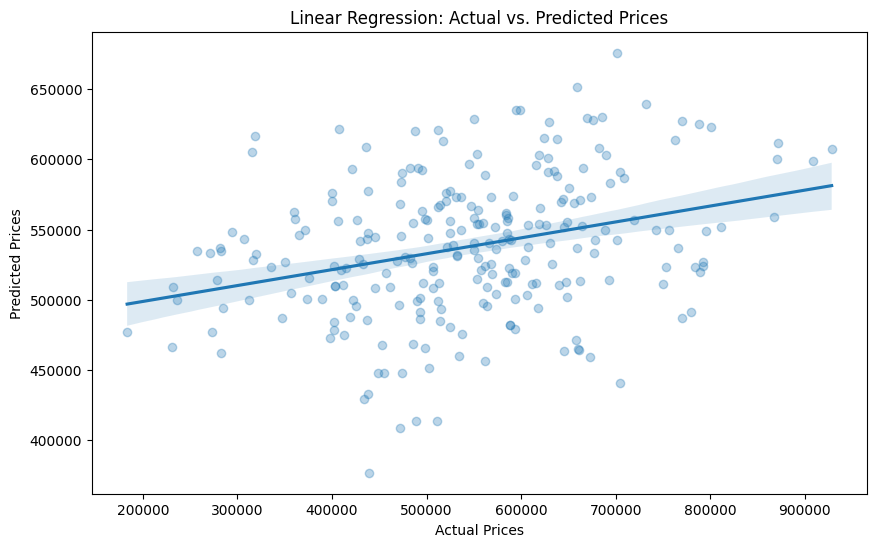

In [43]:
if X_train_scaled is not None:

    lr_model = LinearRegression()

    lr_model.fit(X_train_scaled, y_train)

    y_pred_lr = lr_model.predict(X_test_scaled)

    # Calculate Mean Squared Error (MSE)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    # Calculate R-squared (R2)
    r2_lr = r2_score(y_test, y_pred_lr)

    print(f"Linear Regression - Mean Squared Error (MSE): {mse_lr:.2f}")
    print(f"Linear Regression - R-squared (R2): {r2_lr:.2f}")

    # Plot actual prices against predicted prices to visually check the model's performance.
    # A perfect model would show all points on a straight diagonal line.
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=y_pred_lr, scatter_kws={'alpha':0.3}) # 'alpha' makes points semi-transparent
    plt.title('Linear Regression: Actual vs. Predicted Prices')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.show()
else:
    print("Skipping Linear Regression as data is not available.")

Polynomial Regression (degree=2) - Mean Squared Error (MSE): 8160412416.11
Polynomial Regression (degree=2) - R-squared (R2): 0.57


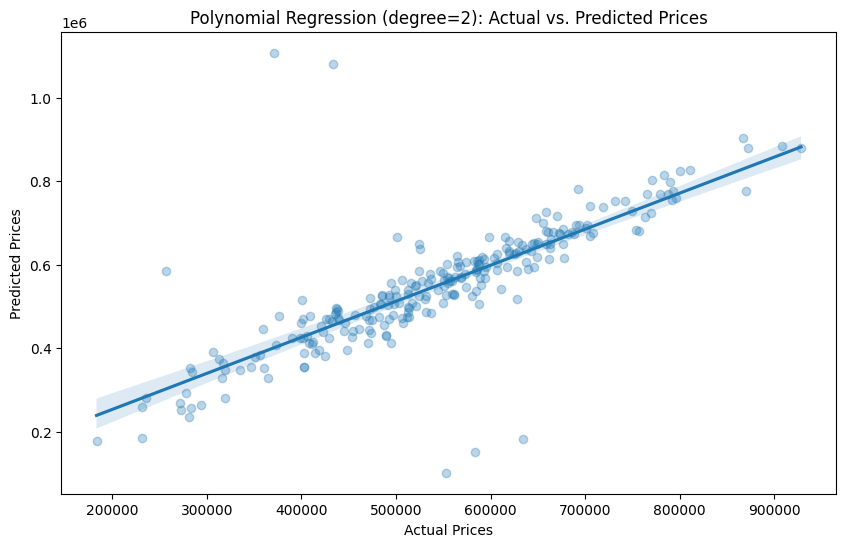

In [46]:
if X_train_scaled is not None:
    # You can adjust the degree of the polynomial. A degree of 2 means we add squared terms of the features.
    degree = 2
    # PolynomialFeatures creates new features by raising existing features to a specified power (e.g., Area becomes Area and Area^2).
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train_scaled) # Transform training data
    X_test_poly = poly_features.transform(X_test_scaled)     # Transform testing data

    # We then use a Linear Regression model on these new polynomial features.
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)

    # Evaluate the model's performance using Mean Squared Error (MSE) and R-squared.
    mse_poly = mean_squared_error(y_test, y_pred_poly)
    r2_poly = r2_score(y_test, y_pred_poly)

    print(f"Polynomial Regression (degree={degree}) - Mean Squared Error (MSE): {mse_poly:.2f}")
    print(f"Polynomial Regression (degree={degree}) - R-squared (R2): {r2_poly:.2f}")

    # Plot actual vs. predicted prices to visualize how well the model performed.
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=y_pred_poly, scatter_kws={'alpha':0.3})
    plt.title(f'Polynomial Regression (degree={degree}): Actual vs. Predicted Prices')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.show()
else:
    print("Skipping Polynomial Regression as data is not available.")

Ridge Regression (alpha=1.0) - Mean Squared Error (MSE): 17106624992.83
Ridge Regression (alpha=1.0) - R-squared (R2): 0.09


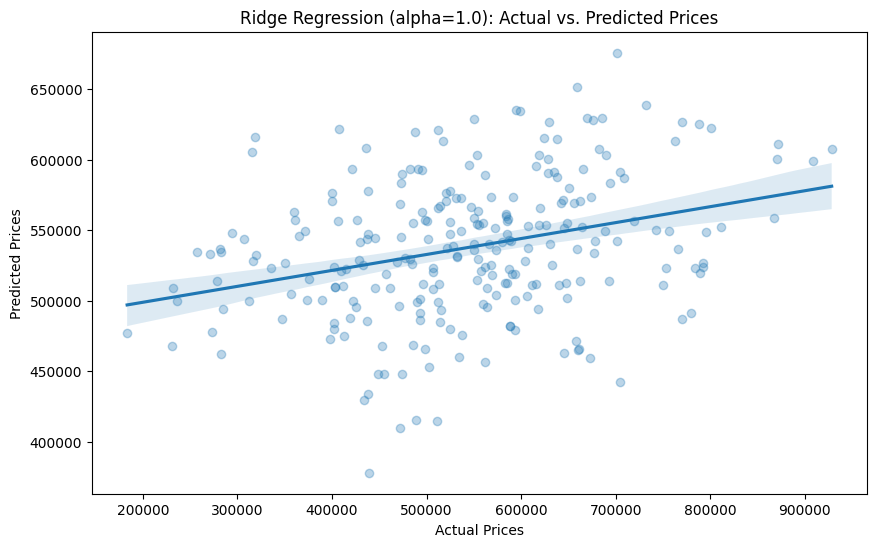

In [47]:
if X_train_scaled is not None:
    # Alpha is the regularization strength; a higher value means a stronger penalty on coefficients.
    # You can tune this value to find the best balance.
    alpha_ridge = 1.0
    # Create a Ridge Regression model with the specified alpha.
    ridge_model = Ridge(alpha=alpha_ridge)
    # Train the model using the scaled training data.
    ridge_model.fit(X_train_scaled, y_train)
    # Predict prices for the test data.
    y_pred_ridge = ridge_model.predict(X_test_scaled)

    # Evaluate the model's performance using MSE and R-squared.
    mse_ridge = mean_squared_error(y_test, y_pred_ridge)
    r2_ridge = r2_score(y_test, y_pred_ridge)

    print(f"Ridge Regression (alpha={alpha_ridge}) - Mean Squared Error (MSE): {mse_ridge:.2f}")
    print(f"Ridge Regression (alpha={alpha_ridge}) - R-squared (R2): {r2_ridge:.2f}")

    # Plot actual vs. predicted prices.
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=y_pred_ridge, scatter_kws={'alpha':0.3})
    plt.title(f'Ridge Regression (alpha={alpha_ridge}): Actual vs. Predicted Prices')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.show()
else:
    print("Skipping Ridge Regression as data is not available.")

Lasso Regression (alpha=0.1) - Mean Squared Error (MSE): 17109890321.40
Lasso Regression (alpha=0.1) - R-squared (R2): 0.09


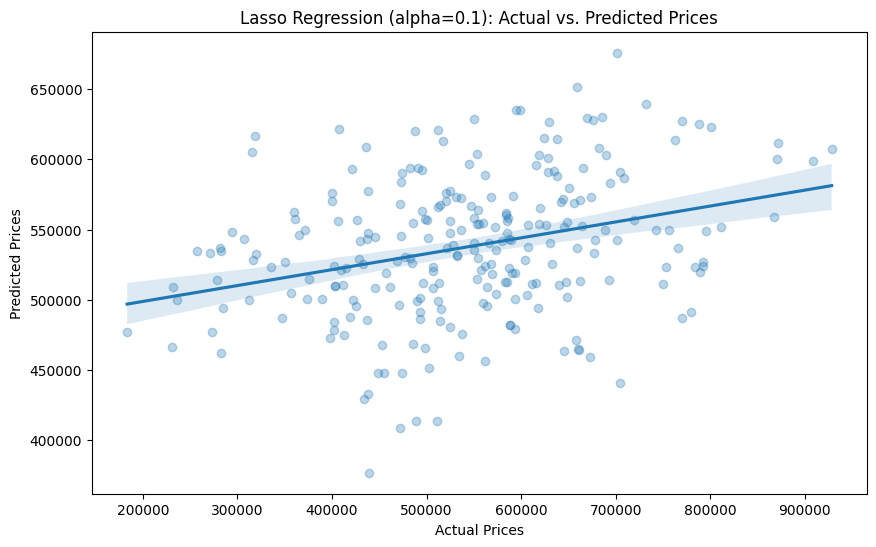

In [48]:
if X_train_scaled is not None:
    # Alpha is the regularization strength. A higher alpha means a stronger penalty.
    alpha_lasso = 0.1
    # Initialize and train the Lasso Regression model.
    # `max_iter` is increased to ensure the model has enough steps to find a solution.
    lasso_model = Lasso(alpha=alpha_lasso, max_iter=2000)
    lasso_model.fit(X_train_scaled, y_train)
    y_pred_lasso = lasso_model.predict(X_test_scaled)

    # Evaluate the model's performance using Mean Squared Error (MSE) and R-squared.
    mse_lasso = mean_squared_error(y_test, y_pred_lasso)
    r2_lasso = r2_score(y_test, y_pred_lasso)

    print(f"Lasso Regression (alpha={alpha_lasso}) - Mean Squared Error (MSE): {mse_lasso:.2f}")
    print(f"Lasso Regression (alpha={alpha_lasso}) - R-squared (R2): {r2_lasso:.2f}")

    # Plot actual vs. predicted prices to visualize how well the model performed.
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=y_pred_lasso, scatter_kws={'alpha':0.3})
    plt.title(f'Lasso Regression (alpha={alpha_lasso}): Actual vs. Predicted Prices')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.show()
else:
    print("Skipping Lasso Regression as data is not available.")

Elastic Net Regression (alpha=0.5, l1_ratio=0.5) - Mean Squared Error (MSE): 17156170779.62
Elastic Net Regression (alpha=0.5, l1_ratio=0.5) - R-squared (R2): 0.09


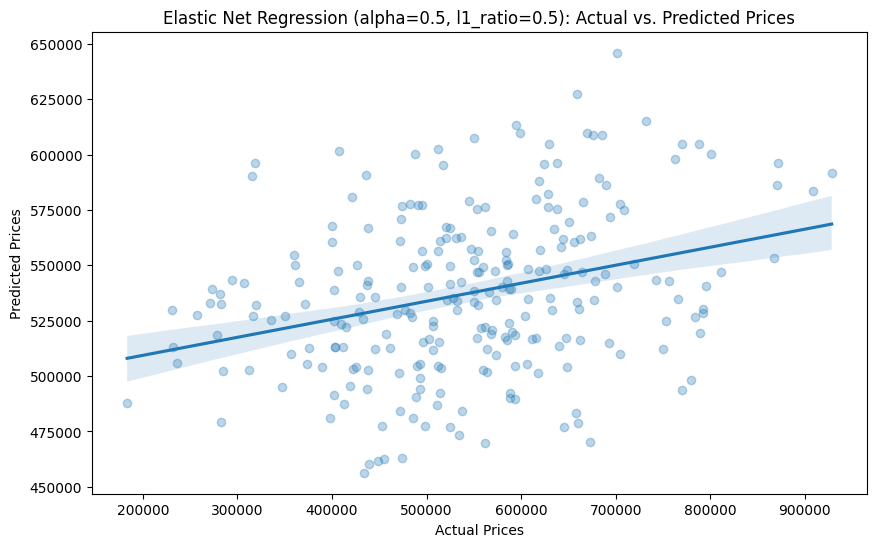

In [49]:
if X_train_scaled is not None:
    # Alpha is the regularization strength, l1_ratio is the mix ratio between Lasso and Ridge (0 = Ridge, 1 = Lasso)
    alpha_enet = 0.5
    l1_ratio_enet = 0.5
    enet_model = ElasticNet(alpha=alpha_enet, l1_ratio=l1_ratio_enet, max_iter=2000) # Increased max_iter
    enet_model.fit(X_train_scaled, y_train)
    y_pred_enet = enet_model.predict(X_test_scaled)

    mse_enet = mean_squared_error(y_test, y_pred_enet)
    r2_enet = r2_score(y_test, y_pred_enet)

    print(f"Elastic Net Regression (alpha={alpha_enet}, l1_ratio={l1_ratio_enet}) - Mean Squared Error (MSE): {mse_enet:.2f}")
    print(f"Elastic Net Regression (alpha={alpha_enet}, l1_ratio={l1_ratio_enet}) - R-squared (R2): {r2_enet:.2f}")

    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=y_pred_enet, scatter_kws={'alpha':0.3})
    plt.title(f'Elastic Net Regression (alpha={alpha_enet}, l1_ratio={l1_ratio_enet}): Actual vs. Predicted Prices')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.show()
else:
    print("Skipping Elastic Net Regression as data is not available.")


Model Performance Comparison:


,Model,MSE,R-squared
1,Polynomial Regression,8.160412e+09,0.568043
2,Ridge Regression,1.710662e+10,0.094491
3,Lasso Regression,1.710989e+10,0.094318
0,Linear Regression,1.710991e+10,0.094317
4,Elastic Net,1.715617e+10,0.091868


/tmp/ipykernel_4617/2515102276.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R-squared', y='Model', data=comparison_df_sorted, ax=axes[0], palette='viridis')
/tmp/ipykernel_4617/2515102276.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MSE', y='Model', data=comparison_df.sort_values(by='MSE', ascending=True), ax=axes[1], palette='magma')


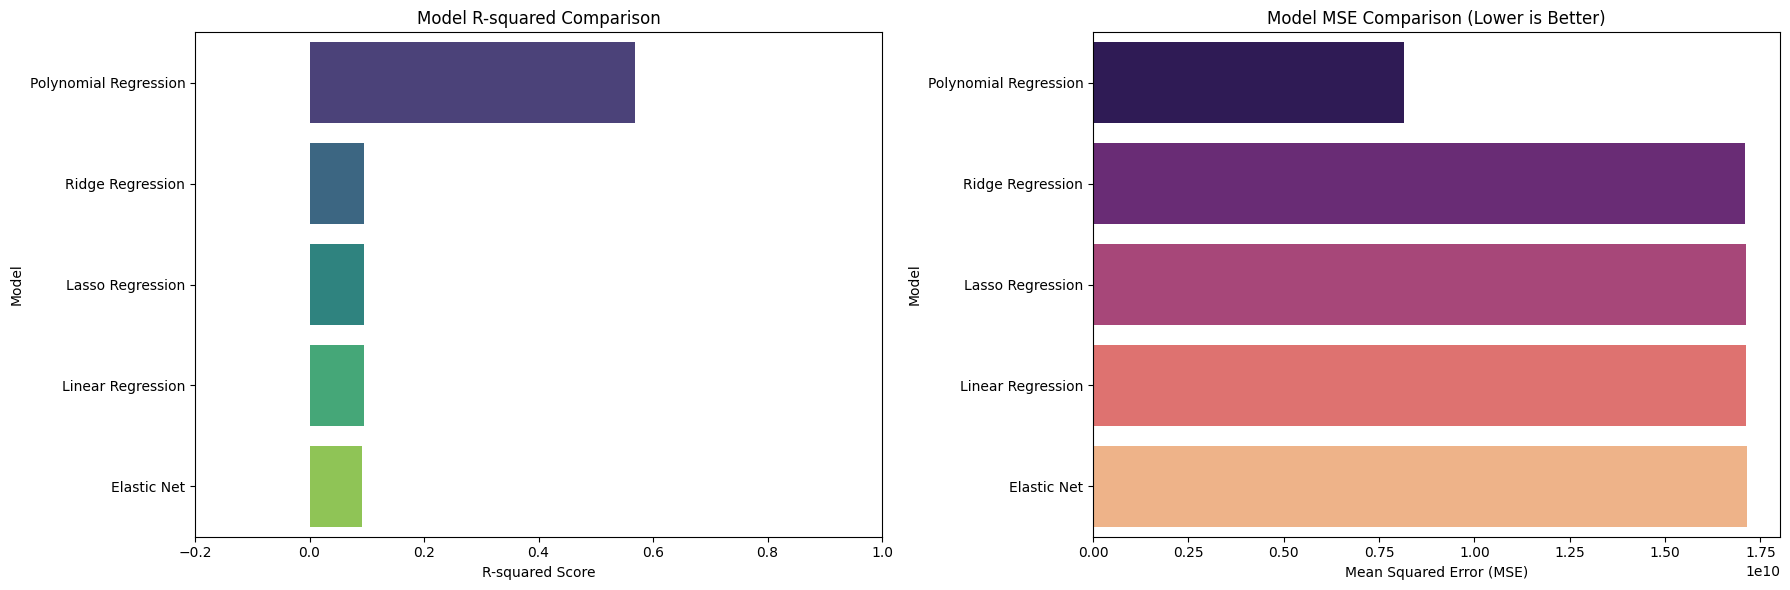

In [50]:
if all(v is not None for v in [mse_lr, r2_lr, mse_poly, r2_poly, mse_ridge, r2_ridge, mse_lasso, r2_lasso, mse_enet, r2_enet]):
    # Create a table (DataFrame) to hold the results of all models.
    comparison_df = pd.DataFrame({
        'Model': ['Linear Regression', 'Polynomial Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net'],
        'MSE': [mse_lr, mse_poly, mse_ridge, mse_lasso, mse_enet],
        'R-squared': [r2_lr, r2_poly, r2_ridge, r2_lasso, r2_enet]
    })

    # Sort the comparison table by R-squared score (highest first) to easily see the best performing model.
    comparison_df_sorted = comparison_df.sort_values(by='R-squared', ascending=False)

    print("\nModel Performance Comparison:")
    display(comparison_df_sorted)

    # Create two plots side-by-side to visualize the R-squared and MSE scores.
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Plot R-squared scores for each model.
    sns.barplot(x='R-squared', y='Model', data=comparison_df_sorted, ax=axes[0], palette='viridis')
    axes[0].set_title('Model R-squared Comparison')
    axes[0].set_xlabel('R-squared Score')
    axes[0].set_ylabel('Model')
    axes[0].set_xlim([-0.2, 1.0]) # Set the range for the R-squared axis.

    # Plot Mean Squared Error (MSE) scores for each model. Lower MSE is better, so we sort in ascending order.
    sns.barplot(x='MSE', y='Model', data=comparison_df.sort_values(by='MSE', ascending=True), ax=axes[1], palette='magma')
    axes[1].set_title('Model MSE Comparison (Lower is Better)')
    axes[1].set_xlabel('Mean Squared Error (MSE)')
    axes[1].set_ylabel('Model')

    plt.tight_layout() # Adjust plot to prevent labels from overlapping.
    plt.show()
else:
    print("Cannot compare models as some performance metrics are not available. Please ensure all model cells were executed.")